# Module 4 Coding Lab: Regression With Housing Prices
**Name:** James Okooboh

## Part 0: Setup

In [1]:
import sklearn
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.9.1


## Part 1: Load & Explore the Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('USA_Housing.csv')
print(df.shape)
print(df.columns.tolist())

(5000, 7)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


In [4]:
display(df.head())
df.info()
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [5]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [6]:
df = df.drop('Address', axis=1)
print(df.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


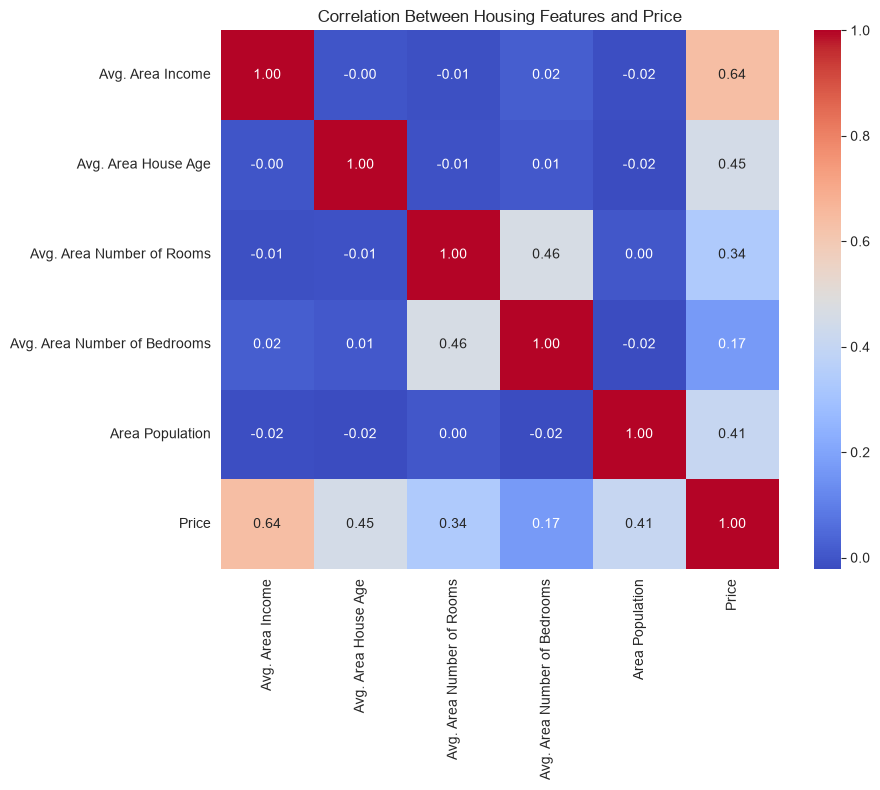

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Housing Features and Price')
plt.show()

**Observation (Part 1):** Avg. Area Income has the strongest correlation with Price (about 0.64), followed by Avg. Area House Age and Area Population. Avg. Area Number of Bedrooms has the weakest (about 0.17). This suggests income will be the most useful single predictor of price, while the number of bedrooms adds little on its own.

## Part 2: Simple Linear Regression

In [8]:
X = df[['Avg. Area Income']]
y = df['Price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 4000
Test size: 1000


In [10]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


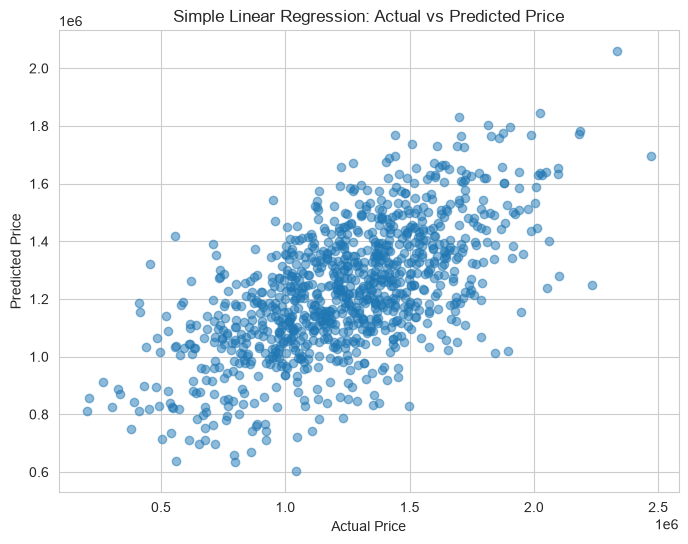

In [11]:
y_pred_simple = model_simple.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_simple, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Simple Linear Regression: Actual vs Predicted Price')
plt.show()

In [12]:
print('Coefficient:', model_simple.coef_[0])
print('Intercept:', model_simple.intercept_)

Coefficient: 21.208906292657513
Intercept: -225053.70287170145


**Observation (Part 2):** The coefficient is about 21.21, which means that for every $1 increase in average area income, the model predicts the house price rises by roughly $21.21 (so a $10,000 increase in income adds about $212,000 to the predicted price). The intercept of about −$225,054 has no real-world meaning, since no area has zero income; it just positions the line. The wide spread in the scatter plot shows income alone explains only part of the variation in price.

## Part 3: Multiple Linear Regression

In [13]:
X_multi = df.drop('Price', axis=1)
y_multi = df['Price']

In [14]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)
print('Train size:', X_train_multi.shape[0])
print('Test size:', X_test_multi.shape[0])

Train size: 4000
Test size: 1000


In [15]:
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [16]:
y_pred_multi = model_multi.predict(X_test_multi)

In [17]:
coeff_df = pd.DataFrame(
    model_multi.coef_, X_multi.columns, columns=['Coefficient']
)
print(coeff_df)

                                Coefficient
Avg. Area Income                  21.652206
Avg. Area House Age           164666.480722
Avg. Area Number of Rooms     119624.012232
Avg. Area Number of Bedrooms    2440.377611
Area Population                   15.270313


**Observation (Part 3):** Avg. Area House Age has the largest coefficient (about 164,666), followed by Avg. Area Number of Rooms (about 119,624). But a larger coefficient does not automatically mean a more important feature, because the columns are on very different scales. One extra year of house age or one extra room is a big change, while one extra dollar of income or one extra person in the population is tiny. That's why Income (21.65) and Population (15.27) have small coefficients even though income is actually the strongest predictor of price (it had the highest correlation in Part 1). To compare importance fairly, the features would need to be standardised to the same scale first.

## Part 4: Evaluating & Comparing Both Models

In [18]:
# Simple model metrics
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple)
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = metrics.r2_score(y_test, y_pred_simple)

print('Simple model metrics:')
print('MAE:', mae_simple)
print('MSE:', mse_simple)
print('RMSE:', rmse_simple)
print('R2:', r2_simple)

# Multiple model metrics
mae_multi = metrics.mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = metrics.mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test_multi, y_pred_multi)

print('\nMultiple model metrics:')
print('MAE:', mae_multi)
print('MSE:', mse_multi)
print('RMSE:', rmse_multi)
print('R2:', r2_multi)

# Comparison table
comparison = pd.DataFrame({
    'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple],
    'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi]
}, index=['MAE', 'MSE', 'RMSE', 'R2'])
print('\n', comparison)

Simple model metrics:
MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766

Multiple model metrics:
MAE: 80879.09723489822
MSE: 10089009300.894522
RMSE: 100444.06055558746
R2: 0.9179971706834288

       Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             8.087910e+04
MSE           7.419489e+10             1.008901e+10
RMSE          2.723874e+05             1.004441e+05
R2            3.969487e-01             9.179972e-01


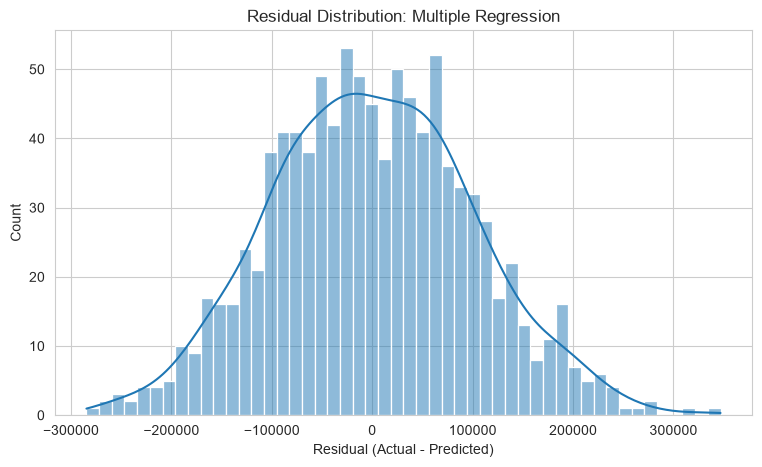

In [19]:
residuals = y_test_multi - y_pred_multi

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Residual Distribution: Multiple Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.show()

**Observation (Part 4):** The multiple regression model performed far better than the simple model. R² rose from about 0.397 to 0.918, meaning the model now explains roughly 92% of the variation in house prices instead of 40%. The average error (MAE) fell from about $216,826 to $80,879, and RMSE fell from about $272,387 to $100,444, both reductions of roughly 63%. Adding the extra features was clearly worth it.

The residual histogram is roughly bell-shaped, symmetric, and centred around zero, with most errors falling between about −$200,000 and +$200,000. This suggests the errors are approximately normally distributed and the model is not consistently over- or under-predicting prices, which is what we expect from a well-behaved linear regression model.

## Part 5: Polynomial Regression

In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = model_poly.predict(X_test_poly)

r2_poly = metrics.r2_score(y_test_poly, y_pred_poly)
print('Polynomial R2:', r2_poly)
print('Simple linear R2:', r2_simple)
print('Difference:', r2_poly - r2_simple)

Polynomial R2: 0.3939626768410842
Simple linear R2: 0.39694865192619766
Difference: -0.002985975085113446
